In [1]:
import numpy as np

In [2]:
class KNearestNeighborsRegressor:

    def __init__(self, n_neighbors=5, random_state=42) -> None:

        np.random.seed(random_state)
        self.n_neighbors = n_neighbors

    
    def predict(self, X):

        X = X.reshape(-1, 1, X.shape[-1])

        distance = np.sqrt(np.square((self.x - X)).sum(axis=-1))
        argmn = np.argsort(distance, axis=1)
        kNeighbors_indices = argmn[:, :self.n_neighbors]
        kNeighbors = self.y[kNeighbors_indices]

        return np.mean(kNeighbors, axis=1)
        

    def fit(self, X, y):

        self.x = X
        self.y = y

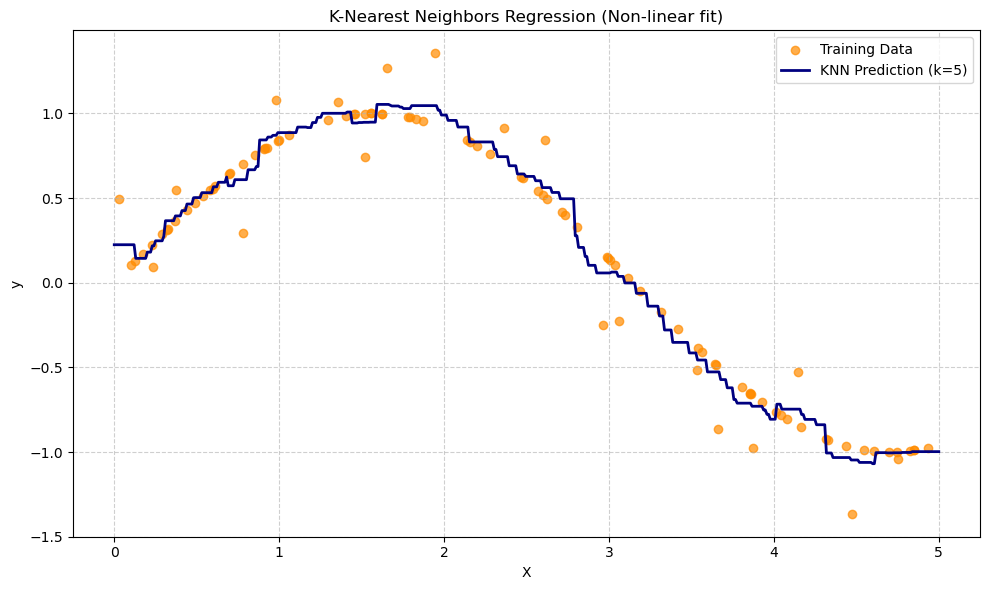

In [3]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)
X_train = np.sort(5 * np.random.rand(100, 1), axis=0)
y_train = np.sin(X_train).ravel()
y_train[::5] += 1 * (0.5 - np.random.rand(20)) 


model = KNearestNeighborsRegressor(n_neighbors=5)
model.fit(X_train, y_train)


X_test = np.linspace(0, 5, 500).reshape(-1, 1)
y_pred = model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='darkorange', label='Training Data', alpha=0.7)
plt.plot(X_test, y_pred, color='navy', label='KNN Prediction (k=5)', linewidth=2)

plt.title("K-Nearest Neighbors Regression (Non-linear fit)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()